# Setup and download data

This tutorials shows how to set up a CosMx (image-based spatial transcriptomics) dataset from [Melton, Jimenez, et al., 2025](https://www.science.org/doi/10.1126/sciadv.ady0080). The data contains six nPOD organ donors—three with Type 1 Diabetes (T1D) and three no diabetes (ND). To follow along with this and the following tutorials, please execute the following steps first:

- Set up InterScale environment (see instructions in ReadMe)
- Download the sample data from the original publication from [Zenodo](https://zenodo.org/records/14870961) <mark>NOTE: Access only restricted, can we make subset available?</mark>

In [1]:
import scanpy as sc
import squidpy as sq
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.sparse import issparse
import seaborn as sns

from pathlib import Path

/usr/local/lib/python3.10/dist-packages/optuna/study/_optimize.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from optuna import progress_bar as pbar_module
/usr/local/lib/python3.10/dist-packages/anndata/utils.py:434: FutureWarning: Importing read_csv from `anndata` is deprecated. Import anndata.io.read_csv instead.
  warnings.warn(msg, FutureWarning)
/usr/local/lib/python3.10/dist-packages/anndata/utils.py:434: FutureWarning: Importing read_excel from `anndata` is deprecated. Import anndata.io.read_excel instead.
  warnings.warn(msg, FutureWarning)
/usr/local/lib/python3.10/dist-packages/anndata/utils.py:434: FutureWarning: Importing read_hdf from `anndata` is deprecated. Import anndata.io.read_hdf instead.
  warnings.warn(msg, FutureWarning)
/usr/local/lib/python3.10/dist-packages/anndata/utils.py:434: FutureWarning: Importing read_loom from `anndata` is deprecated. Import anndata.io.

In [2]:
from pathlib import Path

# set INTERSCALE_DIR to the current working directory
INTERSCALE_DIR = Path.cwd()
print(INTERSCALE_DIR)

/workspace


<mark>TODO: Change data path</mark>

In [3]:
COSMX_PANCREAS = '/dss/dssfs03/tumdss/pn36po/pn36po-dss-0002/di93tig/Projects/A3_InterScale/data/melton25.h5ad'  

## Load data

In [4]:
adata_pancreas = sc.read_h5ad(COSMX_PANCREAS)
adata_pancreas

AnnData object with n_obs × n_vars = 386727 × 979
    obs: 'fov', 'Area', 'AspectRatio', 'CenterX_global_px', 'CenterY_global_px', 'Width', 'Height', 'Mean.MembraneStain', 'Max.MembraneStain', 'Mean.PanCK', 'Max.PanCK', 'Mean.GCG', 'Max.GCG', 'Mean.CD3', 'Max.CD3', 'Mean.DAPI', 'Max.DAPI', 'cell_ID', 'condition', 'slide', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_NegPrb', 'log1p_total_counts_NegPrb', 'pct_counts_NegPrb', 'n_genes', 'cell_type_coarse', 'CellTypes_max', 'slide_fov', 'slide_condition', 'split', 'split_0', 'split_1', 'split_2', 'globalX', 'globalY', 'sliding_window_square', 'sliding_window_h', 'sliding_window_v'
    obsm: 'X_pca', 'X_umap', 'spatial', 'spatial_fov'
    layers: 'counts'

Important variables in this dataset are:

- `slide`: three slides with each two donors (one from each condition)
- `fov`: Field of views per slide
- `slide_fov`: compbined slides and FOVs (use this as `library_key`)
- `slide_condition`: combined slide and condition information

## 1. Normalization

The data needs to be normalized (ideally in a range from 0 to 3.0) for InterScale. Check if the data is already normalized: 

In [8]:
print(f'Min count: {adata_pancreas.X.min()}, Max count: {adata_pancreas.X.max()}')

Min count: 0.0, Max count: 4.81278657913208


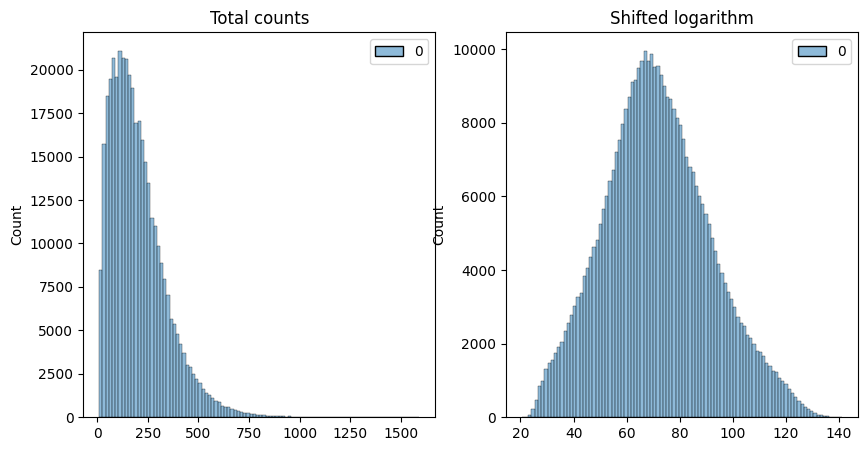

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
p1 = sns.histplot(adata_pancreas.layers["counts"].sum(1), bins=100, kde=False, ax=axes[0])
axes[0].set_title("Total counts")
p2 = sns.histplot(adata_pancreas.X.sum(1), bins=100, kde=False, ax=axes[1])
axes[1].set_title("Shifted logarithm")
plt.show()

The data is already normalized and saved to adata.X which is InterScale uses by default.

## 2. Calculate spatial connectivity matrix

Use [`squidpy.gr.spatial_neighbors()`](https://squidpy.readthedocs.io/en/stable/api/squidpy.gr.spatial_neighbors.html)) to calculate the spatial connectivity. For image-based ST it is important to set `coord_type='generic'`. In Squidpy, you have the option between k-nearest neighbors, delaunay and radius based neighborhood. For InterScale, we use a radius-based neighborhood to capture density information. Find the radius for which the number of connected neighbors is approximately 10-30, depending on tissue density. 

In [44]:
sq.gr.spatial_neighbors(
    adata_pancreas,
    coord_type = "generic",
    library_key = "slide_fov",
    radius = 110,
)

In [45]:
# Calculate nr. of neighbors per cells
conn = adata_pancreas.obsp['spatial_connectivities']
# Print average number of connections per node
avg_connections = conn.nnz / conn.shape[0]  # total connections / number of nodes
print(f"Average number of connections per node: {avg_connections:.2f}")

Average number of connections per node: 10.79


In [46]:
np.unique(adata_pancreas.obs['slide_fov'])

array(['1_1', '1_10', '1_11', '1_12', '1_13', '1_14', '1_15', '1_16',
       '1_17', '1_18', '1_19', '1_2', '1_20', '1_21', '1_22', '1_23',
       '1_24', '1_3', '1_4', '1_5', '1_6', '1_7', '1_8', '1_9', '2_1',
       '2_10', '2_11', '2_12', '2_13', '2_14', '2_15', '2_16', '2_17',
       '2_18', '2_19', '2_2', '2_20', '2_21', '2_22', '2_3', '2_4', '2_5',
       '2_6', '2_7', '2_8', '2_9', '3_1', '3_10', '3_11', '3_12', '3_13',
       '3_14', '3_15', '3_16', '3_17', '3_18', '3_19', '3_2', '3_20',
       '3_21', '3_22', '3_23', '3_24', '3_25', '3_3', '3_4', '3_5', '3_6',
       '3_7', '3_8', '3_9'], dtype=object)

/usr/local/lib/python3.10/dist-packages/squidpy/pl/_spatial_utils.py:976: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(
/usr/local/lib/python3.10/dist-packages/squidpy/pl/_spatial_utils.py:976: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(


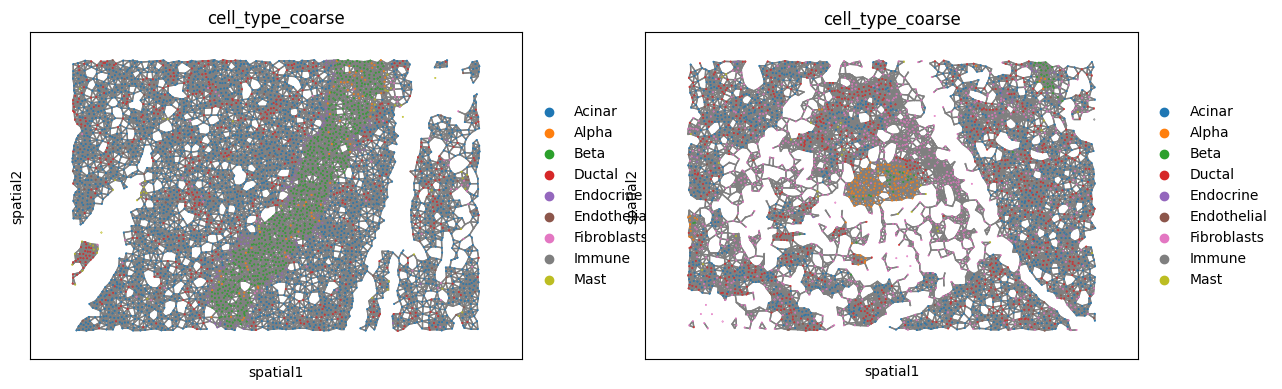

In [47]:
sq.pl.spatial_scatter(
    adata_pancreas,
    library_key='slide_fov',
    library_id = ['1_1', '1_21'],
    connectivity_key="spatial_connectivities",
    color=["cell_type_coarse"],
    shape=None
)

## 3. Optional: Calculate sliding windows

Sliding windows are necessary in case the tissue slide contains more than 4k cells. First, check how many cells are at minimum or maximum in your dataset.

In [13]:
tissue_cell_number = adata_breast.obs.groupby('batch').size()
print(f"Nr cells per sliding window: Min: {tissue_cell_number.min()}, Max: {tissue_cell_number.max()}, Avg: {tissue_cell_number.mean()}")

Nr cells per sliding window: Min: 496, Max: 4875, Avg: 2546.8333333333335


/tmp/ipykernel_2336676/1736762428.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tissue_cell_number = adata_breast.obs.groupby('batch').size()


In [48]:
tissue_cell_number.plot(kind='bar', color='steelblue', edgecolor='black')

We observe that there are a slides with only a few cells but 2 slides with more than 4k cells. For this case we have the option to 1) increase the context length to max = 4875 or 2) calculate sliding windows for all slides that have more than 3k cells. 

In [16]:
batches_over_4k = tissue_cell_number[tissue_cell_number > MAX_CELLS]
print(batches_over_4k)

batch
7     4875
10    4744
dtype: int64


In [30]:
del adata_breast.obs['sliding_window_assignment']

In [43]:
sq.tl.sliding_window(
    adata=adata_breast,
    library_key="batch",  # to stratify by sample
    window_size=10000,
    overlap=0,
    copy=False,  # we modify in place
)

In [44]:
window_size = adata_breast.obs.groupby('sliding_window_assignment').size()
print(f"Nr cells per sliding window: Min: {window_size.min()}, Max: {window_size.max()}, Avg: {window_size.mean()}")

Nr cells per sliding window: Min: 57, Max: 2418, Avg: 985.8709677419355


/tmp/ipykernel_2336676/2739523918.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  window_size = adata_breast.obs.groupby('sliding_window_assignment').size()


In [49]:
sq.pl.spatial_scatter(
    adata_breast,
    spatial_key = 'spatial',
    library_key='batch', 
    color="sliding_window_assignment", #cell_type_coarse",
    size = 10,
)

With the sliding windows the maximum number of cells per sliding window is `2418`. 

<mark>TODO: Adjust max_seq_len in config file!</mark>
Given this we adjust the `max_seq_len` from the model.global_component to `2418`. The default is `2000`.

## Save adata object

Save the prepared adata object such that it can be loaded for the model training. 

In [46]:
adata_breast.write('/dss/dssfs03/tumdss/pn36po/pn36po-dss-0002/di93tig/Projects/A3_InterScale/data/visium_tme_pp.h5ad'  )

## Prepare config file

Duplicate the minum requirement config file from `/GT-long-range-niches/src/config_files/InterScale_example.yaml` and add the necessary specification for the Visum data:

```
model:
  local_component:
    name: GCN
  global_component:
    name: self-attn-transformer
        max_seq_len: 2418
  save: /path/to/save/model/
dataset:
  h5ad_data: visium_tme_pp.h5ad
  name: Visium_breast_cancer_TME
  sample_key: ['batch']
  spatial_neigbors_kwargs:
    coord_type: grid
    library_key: batch
```


Save the config file as `.yaml` and proceed to training (either interactively in jupyter notebook or by running a script).

## Train, test and val split

Split data into train, val and test set. Each set contains two patients, one from each condition. 